# 9 - Advanced Models: Histogram Gradient Boosting & Random Forest

Per the advanced-model-selection in Section 4.5, two pre-registered models are evaluated against the
elastic-net logistic-regression baseline: histogram gradient boosting (primary; bias reduction)
and random forest (contrast; variance reduction). Both test the one baseline weakness a model
change can address - the inability to capture non-linear feature interactions. Everything else is
held identical to the baseline: the time-ordered split, Tier-1 evaluation scope, imbalanced-class
metrics, and the rolling-origin backtest. Interpretability is recovered with SHAP , used specifically to test whether coercion content adds value beyond attention volume.


In [17]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, matplotlib as mpl
from pathlib import Path
import warnings; warnings.filterwarnings("ignore")
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import (average_precision_score, roc_auc_score, matthews_corrcoef,
    balanced_accuracy_score, f1_score, precision_score, recall_score, precision_recall_curve)
mpl.rcParams.update({"figure.dpi":120,"savefig.dpi":200,"font.size":11,"axes.grid":True,
    "grid.alpha":0.25,"axes.spines.top":False,"axes.spines.right":False,"figure.autolayout":True})
ACCENT="#1F3864"; ORANGE="#C55A11"; RED="#B22222"; TEAL="#2E7D6F"
DATA=Path("data"); FIG=Path("eda_figures"); FIG.mkdir(exist_ok=True)
data=pd.read_parquet(DATA/"modelling_dataset.parquet").reset_index()
data['month']=pd.to_datetime(data['month']); data=data.sort_values('month').reset_index(drop=True)
FEATURES=[c for c in data.columns if 'rate_' in c]+['avg_tone','sum_log_sources']; HORIZONS=[30,60,90]
TEST_START=data['month'].max()-pd.DateOffset(months=24)
train=data[data['month']<TEST_START].copy(); test_t1=data[(data['month']>=TEST_START)&(data['tier']=='T1')].copy()
months=np.sort(data['month'].unique())
print("features:",len(FEATURES),"| train:",len(train),"| Tier-1 test:",len(test_t1))

features: 17 | train: 2532 | Tier-1 test: 425


In [18]:
def tune(kind,h):
    y=train['y_%dd'%h].values
    if kind=='hgb':
        est=HistGradientBoostingClassifier(class_weight='balanced',max_iter=200,
              early_stopping=False,random_state=0)
        grid={"learning_rate":[0.05,0.1],"max_leaf_nodes":[31],"l2_regularization":[1.0]}
        gs=GridSearchCV(est,grid,scoring="average_precision",cv=TimeSeriesSplit(3),n_jobs=-1).fit(train[FEATURES],y)
    else:
        est=RandomForestClassifier(n_estimators=200,class_weight='balanced_subsample',random_state=0,n_jobs=-1)
        grid={"max_depth":[6,None],"min_samples_leaf":[5]}
        gs=GridSearchCV(est,grid,scoring="average_precision",cv=TimeSeriesSplit(3),n_jobs=-1).fit(train[FEATURES],y)
    return gs.best_estimator_, gs.best_params_
HGB={}; RF={}
for h in HORIZONS:
    HGB[h],ph=tune('hgb',h); RF[h],pr=tune('rf',h)
    print(f"y_{h}d  HGB {ph}  |  RF {pr}")

y_30d  HGB {'l2_regularization': 1.0, 'learning_rate': 0.05, 'max_leaf_nodes': 31}  |  RF {'max_depth': None, 'min_samples_leaf': 5}
y_60d  HGB {'l2_regularization': 1.0, 'learning_rate': 0.05, 'max_leaf_nodes': 31}  |  RF {'max_depth': 6, 'min_samples_leaf': 5}
y_90d  HGB {'l2_regularization': 1.0, 'learning_rate': 0.05, 'max_leaf_nodes': 31}  |  RF {'max_depth': None, 'min_samples_leaf': 5}


In [19]:
def lr_fit(h):
    pipe=Pipeline([("sc",StandardScaler()),("lr",LogisticRegression(penalty="elasticnet",solver="saga",
          class_weight="balanced",l1_ratio=0.5,C=0.1,max_iter=4000,random_state=0))])
    return pipe.fit(train[FEATURES],train['y_%dd'%h].values)
LR={h:lr_fit(h) for h in HORIZONS}
def scores(model,h):
    y=test_t1['y_%dd'%h].values; pr=model.predict_proba(test_t1[FEATURES])[:,1]; pd_=(pr>=0.5).astype(int)
    return dict(PR_AUC=average_precision_score(y,pr),ROC_AUC=roc_auc_score(y,pr),MCC=matthews_corrcoef(y,pd_),
        precision=precision_score(y,pd_,zero_division=0),recall=recall_score(y,pd_),F1=f1_score(y,pd_),
        bal_acc=balanced_accuracy_score(y,pd_))
rows=[]
for h in HORIZONS:
    base=test_t1['y_%dd'%h].mean()
    for name,mdl in [("LogReg",LR[h]),("HistGBM",HGB[h]),("RandomForest",RF[h])]:
        s=scores(mdl,h); s.update({"horizon":f"y_{h}d","model":name,"pos_rate":round(base,3)})
        rows.append(s)
comp=pd.DataFrame(rows)[["horizon","model","pos_rate","PR_AUC","ROC_AUC","MCC","precision","recall","F1","bal_acc"]].round(3)
comp.to_csv(DATA/"advanced_test_comparison.csv",index=False); comp

,horizon,model,pos_rate,PR_AUC,ROC_AUC,MCC,precision,recall,F1,bal_acc
0,y_30d,LogReg,0.160,0.238,0.600,0.120,0.211,0.559,0.306,0.581
1,y_30d,HistGBM,0.160,0.185,0.548,0.014,0.182,0.059,0.089,0.504
2,y_30d,RandomForest,0.160,0.157,0.511,-0.068,0.000,0.000,0.000,0.486
3,y_60d,LogReg,0.282,0.482,0.633,0.111,0.329,0.625,0.431,0.562
4,y_60d,HistGBM,0.282,0.249,0.454,-0.096,0.163,0.067,0.095,0.466
5,y_60d,RandomForest,0.282,0.261,0.465,-0.035,0.253,0.200,0.223,0.484
6,y_90d,LogReg,0.355,0.510,0.609,0.140,0.414,0.656,0.508,0.572
7,y_90d,HistGBM,0.355,0.322,0.433,-0.073,0.280,0.139,0.186,0.471
8,y_90d,RandomForest,0.355,0.305,0.440,-0.102,0.209,0.060,0.093,0.468


In [20]:
def rolling(kind,h,n_folds=4,test_months=6,params=None):
    res=[]
    for k in range(n_folds,0,-1):
        cut=months[-(k*test_months)]
        nxt = months[-((k-1)*test_months)] if (k-1)>0 else None
        tr=data[data['month']<cut]
        te=data[(data['month']>=cut)] if nxt is None else data[(data['month']>=cut)&(data['month']<nxt)]
        te=te[te['tier']=='T1']
        if tr['y_%dd'%h].sum()<10 or te['y_%dd'%h].sum()<3: continue
        if kind=='hgb': m=HistGradientBoostingClassifier(class_weight='balanced',max_iter=200,random_state=0,**(params or {}))
        elif kind=='rf': m=RandomForestClassifier(n_estimators=200,class_weight='balanced_subsample',random_state=0,n_jobs=-1,**(params or {}))
        else:
            m=Pipeline([("sc",StandardScaler()),("lr",LogisticRegression(penalty="elasticnet",solver="saga",
                class_weight="balanced",l1_ratio=0.5,C=0.1,max_iter=4000,random_state=0))])
        m.fit(tr[FEATURES],tr['y_%dd'%h].values)
        pr=m.predict_proba(te[FEATURES])[:,1]; y=te['y_%dd'%h].values
        res.append({"lift":average_precision_score(y,pr)-y.mean(),"ROC":roc_auc_score(y,pr)})
    d=pd.DataFrame(res); return d['lift'].mean(),d['lift'].std(),d['ROC'].mean(),len(d)
bt=[]
for h in HORIZONS:
    for name,kind in [("LogReg","lr"),("HistGBM","hgb"),("RandomForest","rf")]:
        ml,sl,mr,nf=rolling(kind,h)
        bt.append({"horizon":f"y_{h}d","model":name,"folds":nf,
                   "mean_PR_AUC_lift":round(ml,3),"sd_lift":round(sl,3),"mean_ROC_AUC":round(mr,3)})
btf=pd.DataFrame(bt); btf.to_csv(DATA/"advanced_backtest.csv",index=False)
print(btf.to_string(index=False))

horizon        model  folds  mean_PR_AUC_lift  sd_lift  mean_ROC_AUC
  y_30d       LogReg      3             0.100    0.051         0.608
  y_30d      HistGBM      3             0.038    0.014         0.502
  y_30d RandomForest      3             0.071    0.045         0.586
  y_60d       LogReg      3             0.215    0.058         0.676
  y_60d      HistGBM      3             0.003    0.030         0.458
  y_60d RandomForest      3             0.075    0.053         0.569
  y_90d       LogReg      3             0.196    0.017         0.666
  y_90d      HistGBM      3            -0.006    0.065         0.455
  y_90d RandomForest      3             0.033    0.063         0.530


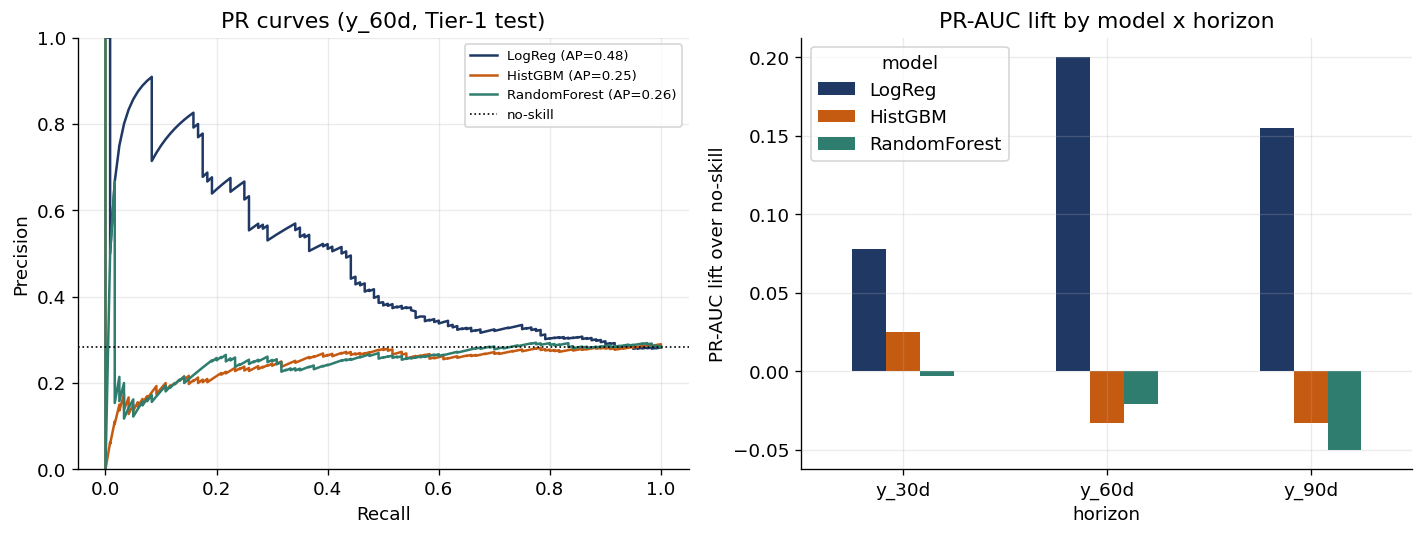

In [21]:
# PR curves at the 60-day horizon; and PR-AUC lift by model x horizon
fig,axes=plt.subplots(1,2,figsize=(12,4.6))
h=60
for name,mdl,col in [("LogReg",LR[h],ACCENT),("HistGBM",HGB[h],ORANGE),("RandomForest",RF[h],TEAL)]:
    y=test_t1['y_%dd'%h].values; pr=mdl.predict_proba(test_t1[FEATURES])[:,1]
    p_,r_,_=precision_recall_curve(y,pr)
    axes[0].plot(r_,p_,color=col,label=f"{name} (AP={average_precision_score(y,pr):.2f})")
axes[0].axhline(test_t1['y_60d'].mean(),color='k',ls=':',lw=1,label='no-skill')
axes[0].set_xlabel("Recall"); axes[0].set_ylabel("Precision"); axes[0].set_ylim(0,1); axes[0].legend(fontsize=8); axes[0].set_title("PR curves (y_60d, Tier-1 test)")
piv=comp.pivot(index='horizon',columns='model',values='PR_AUC')
base=comp.groupby('horizon')['pos_rate'].first()
lift=piv.sub(base,axis=0)
lift[["LogReg","HistGBM","RandomForest"]].plot.bar(ax=axes[1],color=[ACCENT,ORANGE,TEAL])
axes[1].set_ylabel("PR-AUC lift over no-skill"); axes[1].set_title("PR-AUC lift by model x horizon"); axes[1].tick_params(axis='x',rotation=0)
plt.savefig(FIG/"adv_compare.png",bbox_inches='tight'); plt.show()

In [22]:
pip install shap

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


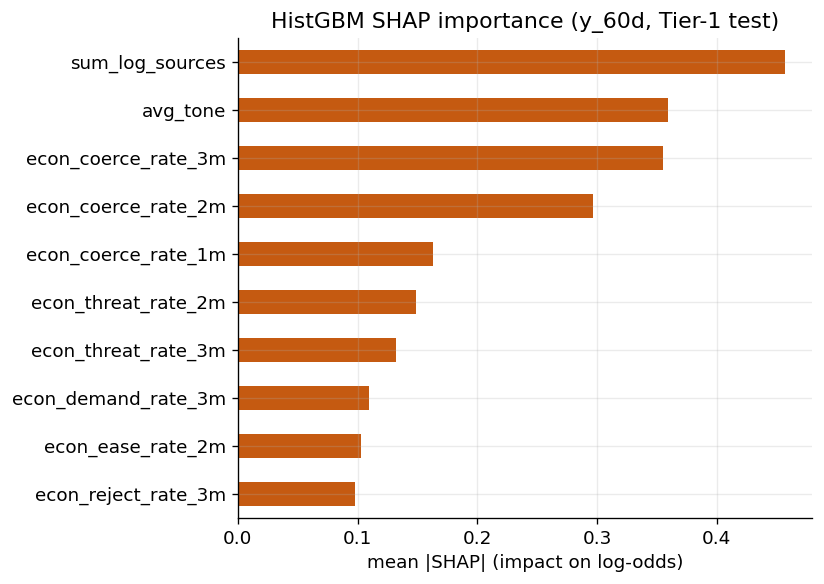

SHAP top features:
sum_log_sources        0.4570
avg_tone               0.3592
econ_coerce_rate_3m    0.3548
econ_coerce_rate_2m    0.2968
econ_coerce_rate_1m    0.1628
econ_threat_rate_2m    0.1488

Content-vs-volume check: rank of econ_coerce_rate_1m vs sum_log_sources
  sum_log_sources: mean|SHAP|=0.4570  (rank 1)
  econ_coerce_rate_1m: mean|SHAP|=0.1628  (rank 5)
  econ_coerce_rate_3m: mean|SHAP|=0.3548  (rank 3)
  econ_threat_rate_1m: mean|SHAP|=0.0746  (rank 12)


In [23]:
import shap
h=60; mdl=HGB[h]
expl=shap.TreeExplainer(mdl); sv=expl.shap_values(test_t1[FEATURES])
sv=sv[1] if isinstance(sv,list) else sv
mean_abs=pd.Series(np.abs(sv).mean(axis=0),index=FEATURES).sort_values()
top=mean_abs.tail(10)
fig,ax=plt.subplots(figsize=(7,5))
top.plot.barh(ax=ax,color=ORANGE); ax.set_xlabel("mean |SHAP| (impact on log-odds)")
ax.set_title(f"HistGBM SHAP importance (y_{h}d, Tier-1 test)")
plt.savefig(FIG/"adv_shap.png",bbox_inches='tight'); plt.show()
rank=mean_abs.sort_values(ascending=False)
print("SHAP top features:"); print(rank.head(6).round(4).to_string())
print("\nContent-vs-volume check: rank of econ_coerce_rate_1m vs sum_log_sources")
for f in ['sum_log_sources','econ_coerce_rate_1m','econ_coerce_rate_3m','econ_threat_rate_1m']:
    if f in rank.index: print(f"  {f}: mean|SHAP|={rank[f]:.4f}  (rank {list(rank.index).index(f)+1})")

In [24]:
print("saved -> data/advanced_test_comparison.csv, data/advanced_backtest.csv")
print("\nTEST (single split):"); print(comp.to_string(index=False))
print("\nBACKTEST (rolling):"); print(btf.to_string(index=False))

saved -> data/advanced_test_comparison.csv, data/advanced_backtest.csv

TEST (single split):
horizon        model  pos_rate  PR_AUC  ROC_AUC    MCC  precision  recall    F1  bal_acc
  y_30d       LogReg     0.160   0.238    0.600  0.120      0.211   0.559 0.306    0.581
  y_30d      HistGBM     0.160   0.185    0.548  0.014      0.182   0.059 0.089    0.504
  y_30d RandomForest     0.160   0.157    0.511 -0.068      0.000   0.000 0.000    0.486
  y_60d       LogReg     0.282   0.482    0.633  0.111      0.329   0.625 0.431    0.562
  y_60d      HistGBM     0.282   0.249    0.454 -0.096      0.163   0.067 0.095    0.466
  y_60d RandomForest     0.282   0.261    0.465 -0.035      0.253   0.200 0.223    0.484
  y_90d       LogReg     0.355   0.510    0.609  0.140      0.414   0.656 0.508    0.572
  y_90d      HistGBM     0.355   0.322    0.433 -0.073      0.280   0.139 0.186    0.471
  y_90d RandomForest     0.355   0.305    0.440 -0.102      0.209   0.060 0.093    0.468

BACKTEST (rollin